In [1]:
from podio.root_io import Reader
reader = Reader( "/data/home/lixp/sim/simple_digi.root" )

Module libc not found.


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


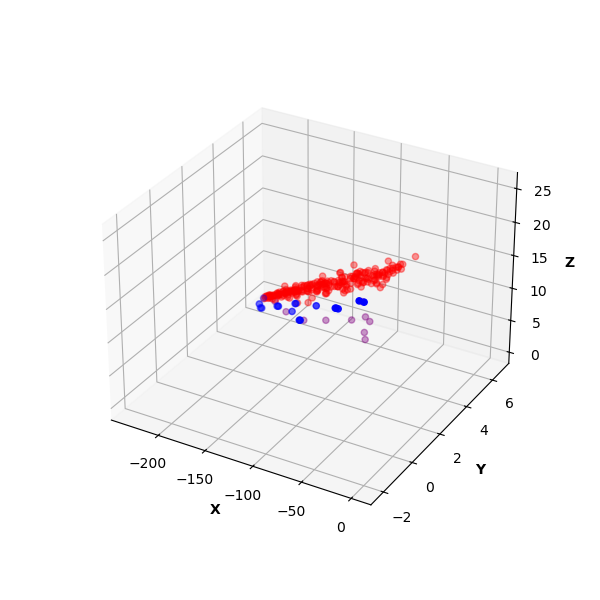

Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numpy as np
from RecoUtils import decodeRawHits, clusterCenter
from Hit3DBuilder import build3d

def plot3d(hits_3d, color = "blue", labels = None, hide_distinct = False, ax = None):
    if ax is None:
        fig = plt.figure()
        ax = plt.axes(projection="3d")
    ax.set_xlabel('X', fontweight='bold')
    ax.set_ylabel('Y', fontweight='bold')
    ax.set_zlabel('Z', fontweight='bold')
    if labels is None:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], color=color)
    else:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], c=labels)
        centers = clusterCenter(hits_3d, labels)
        for c in centers:
            if hide_distinct and c[3] == -1:
                break
            ax.text(c[0], c[1], c[2], int(c[3]))

search_band = 100
tor = 15
drift_velocity = 6

pair_mapper = np.frompyfunc(lambda pair: (pair.x(), pair.y(), pair.time() / 1000 * drift_velocity), 1, 3)
color_mapper = np.frompyfunc(lambda layer: ["red", "purple"][layer], 1, 1)
events = reader.get("events")

fig = plt.figure(figsize=(6, 6))
event  = events[0]
hits   = event.get( "TpcHits" )
dhits =  decodeRawHits(hits)
pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
ax = plt.axes(projection="3d")
plot3d(hits_3d, ax=ax)
ax.scatter3D(dhits.raw_hits[:,0], 
             dhits.raw_hits[:,1], 
             dhits.raw_times / 1000 * drift_velocity, 
             c = color_mapper(dhits.layers),
             alpha = .4)
plt.show()

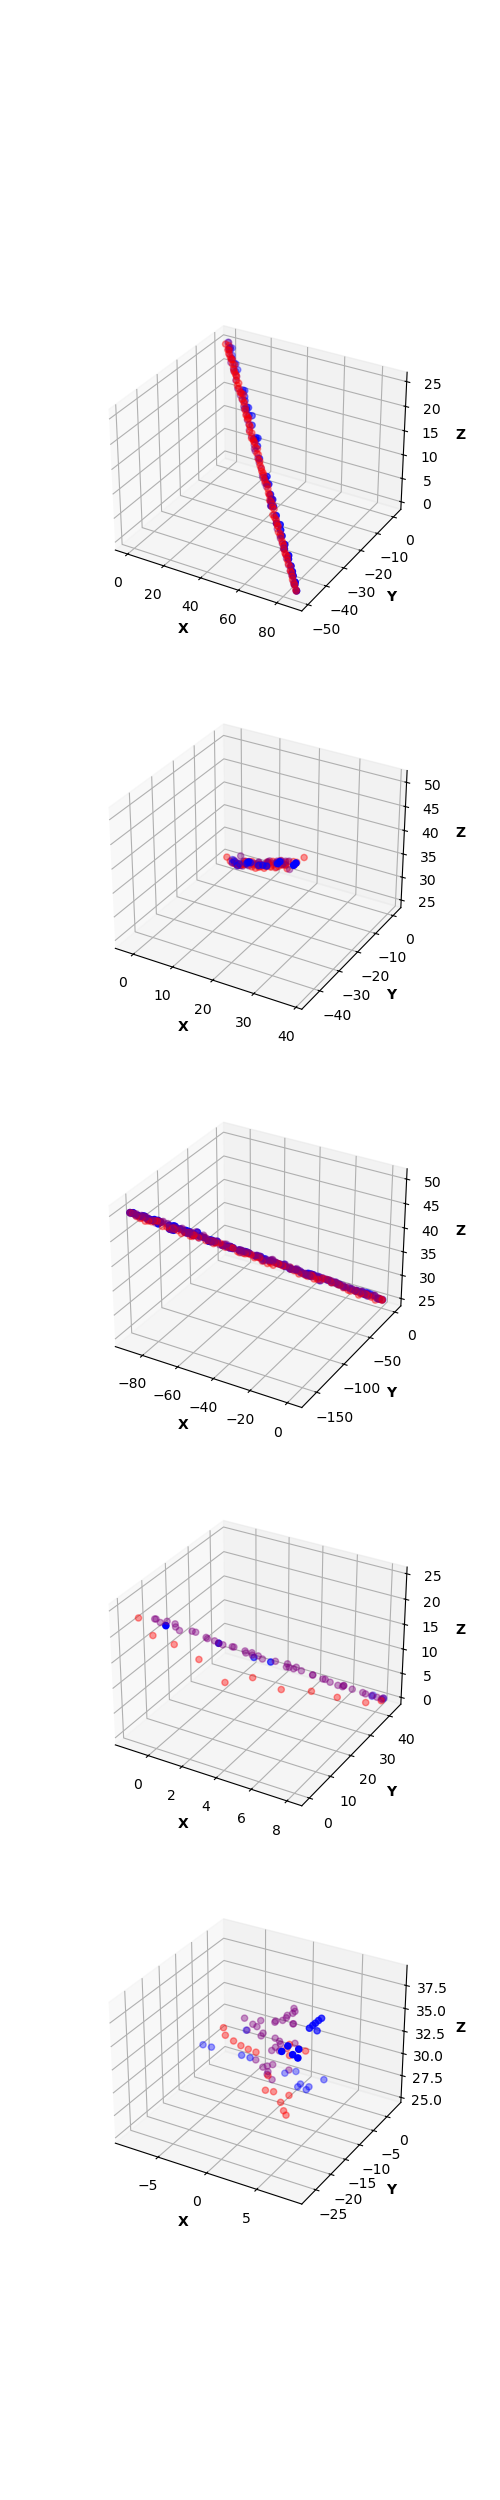

In [3]:
events_to_proc = range(10, 15)
n = len(events_to_proc)
fig = plt.figure(figsize=(5, 5 * n))
for i in range(n):
    event  = events[events_to_proc[i]]
    hits   = event.get( "TpcHits" )
    dhits =  decodeRawHits(hits)
    pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
    hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
    ax = fig.add_subplot(n, 1, 1 + i, projection="3d")
    plot3d(hits_3d, ax=ax)
    ax.scatter(dhits.raw_hits[:,0], 
               dhits.raw_hits[:,1], 
               dhits.raw_times / 1000 * drift_velocity, 
               c = color_mapper(dhits.layers),
               alpha = .4)
plt.show()

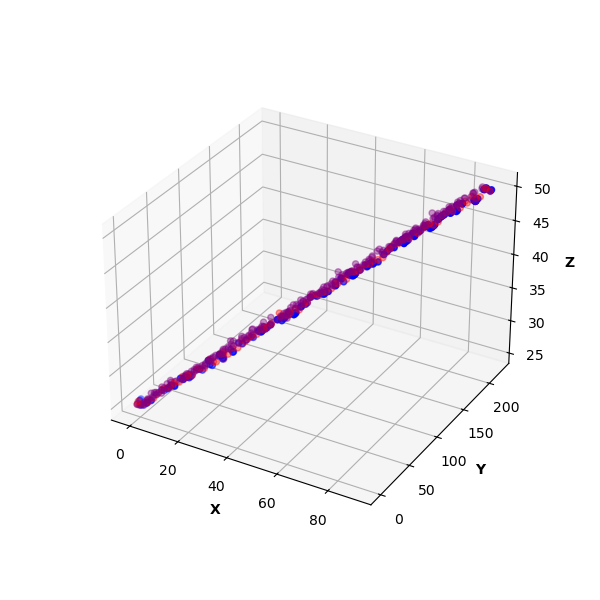

In [4]:
fig = plt.figure(figsize=(6, 6))
event  = events[20]
hits   = event.get( "TpcHits" )
dhits =  decodeRawHits(hits)
pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
ax = plt.axes(projection="3d")
plot3d(hits_3d, ax=ax)
ax.scatter3D(dhits.raw_hits[:,0], 
             dhits.raw_hits[:,1], 
             dhits.raw_times / 1000 * drift_velocity, 
             c = color_mapper(dhits.layers),
             alpha = .4)
plt.show()

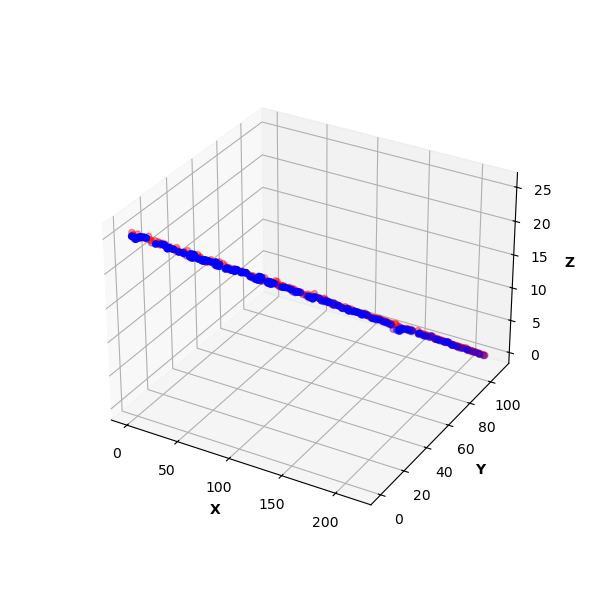

In [5]:
def f (i):
    fig = plt.figure(figsize=(6, 6))
    event  = events[i]
    hits   = event.get( "TpcHits" )
    dhits =  decodeRawHits(hits)
    pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
    hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
    ax = plt.axes(projection="3d")
    plot3d(hits_3d, ax=ax)
    ax.scatter3D(dhits.raw_hits[:,0], 
                dhits.raw_hits[:,1], 
                dhits.raw_times / 1000 * drift_velocity, 
                c = color_mapper(dhits.layers),
                alpha = .4)
    plt.show()

f(16)

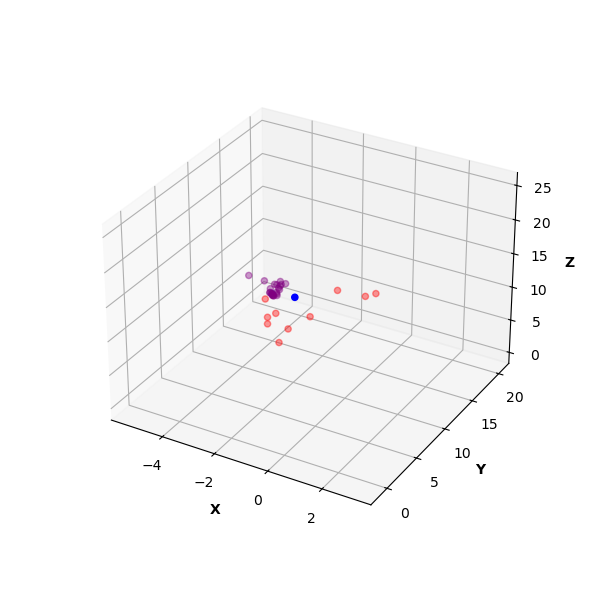

In [6]:
f(17)

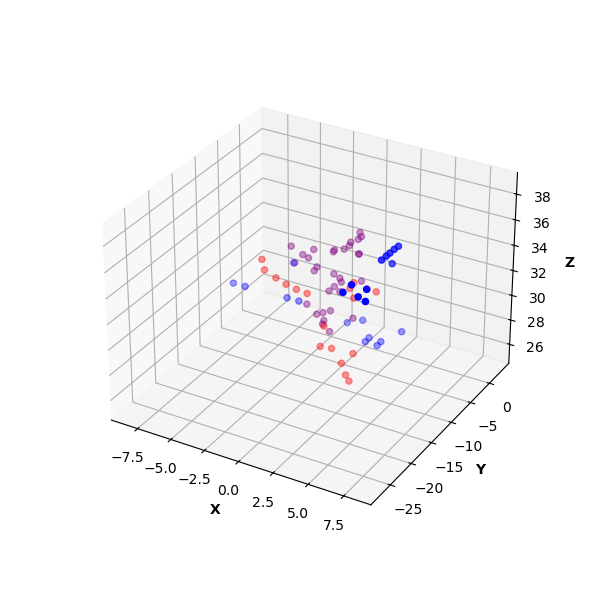

In [7]:
f(14)

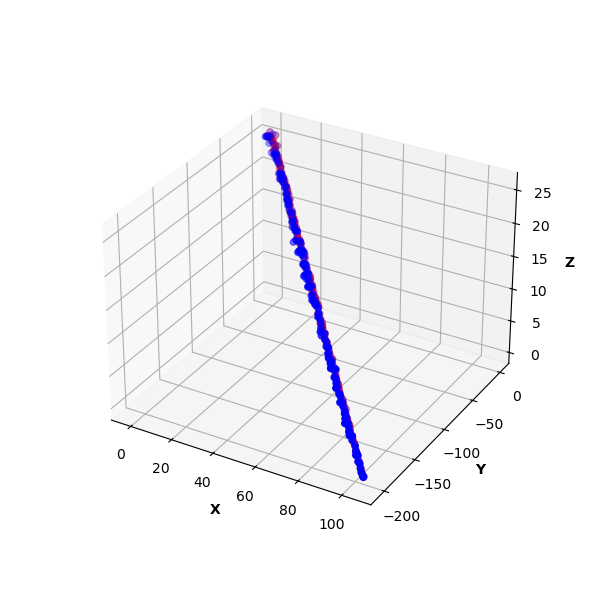

In [8]:
f(21)

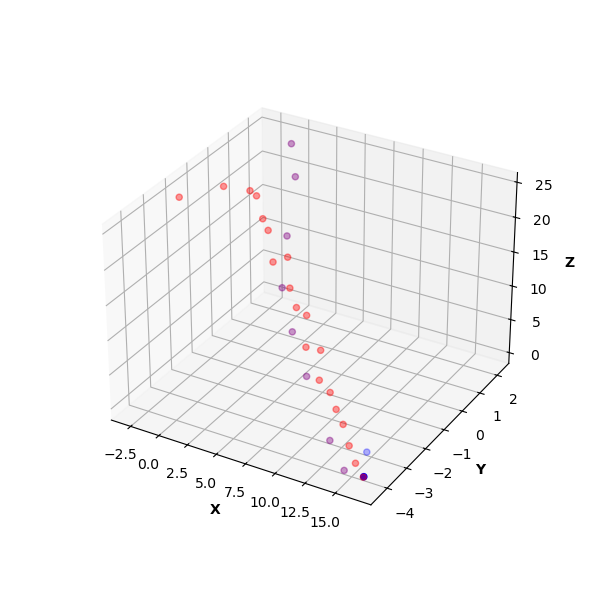

In [9]:
f(22)

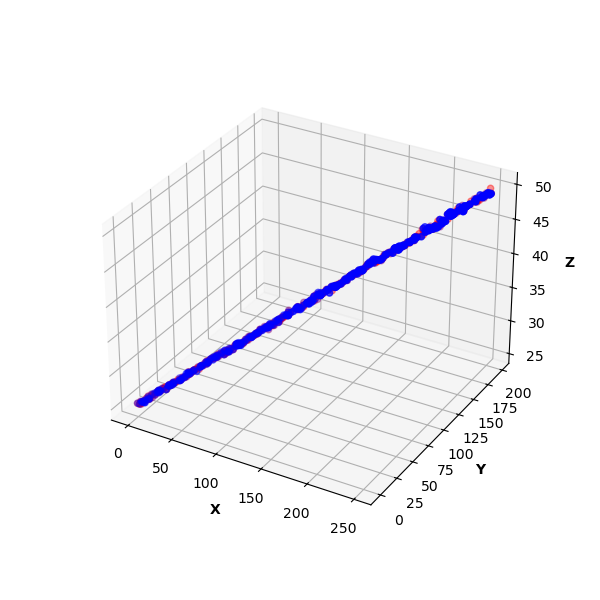

In [10]:
f(23)

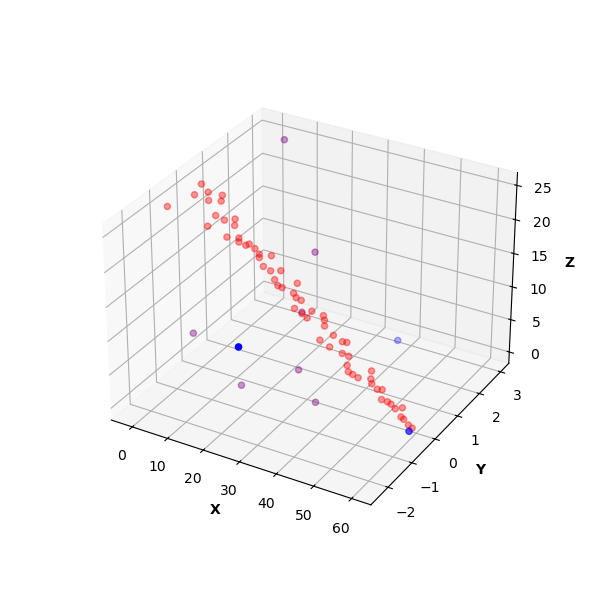

In [11]:
f(24)

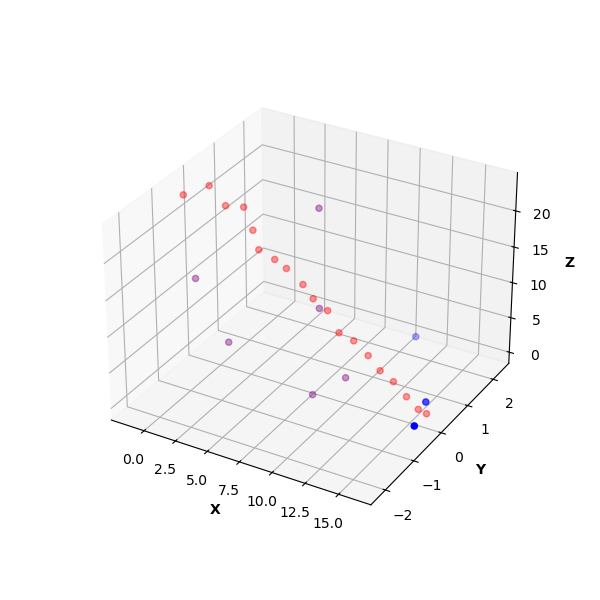

In [12]:
f(25)

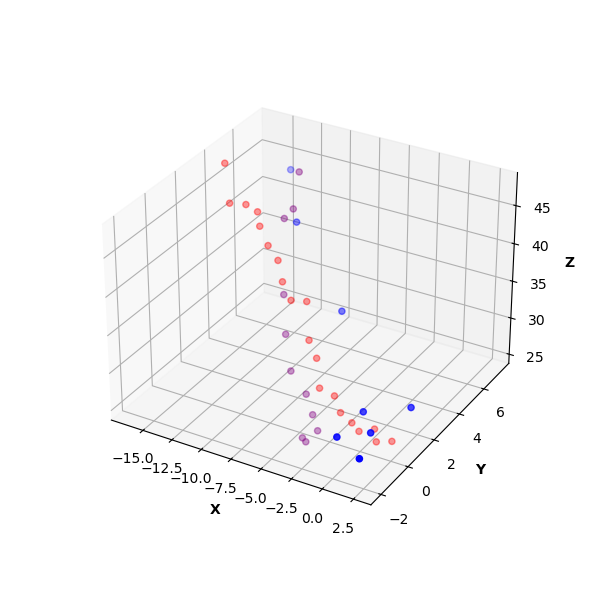

In [13]:
f(26)

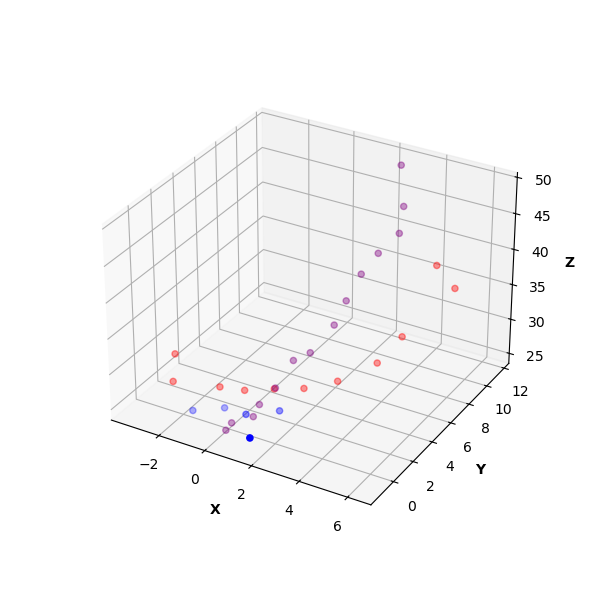

In [14]:
f(27)

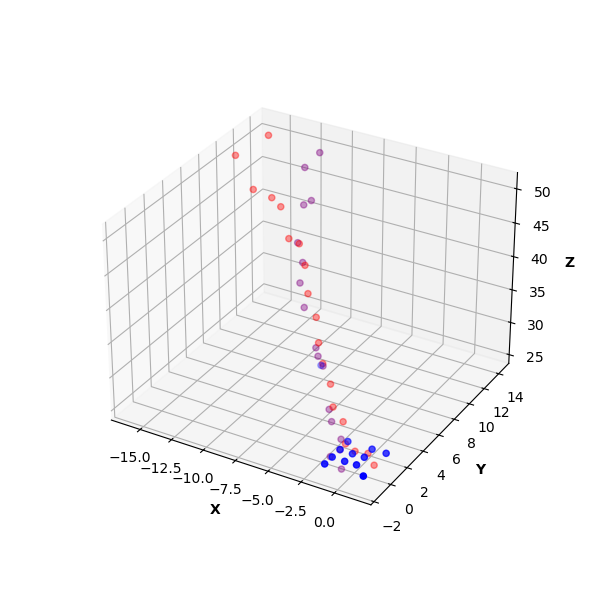

In [15]:
f(2)